<a href="https://colab.research.google.com/github/mahmooda23/Early-Risk-Stratification-of-Maternal-Complications-during-Pregnancy-/blob/main/predict_risk_during_pregnancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report

In [1]:
import pandas as pd
from google.colab import files


uploaded = files.upload()
file_name = 'MaternalHealthRiskDataset.csv'
if file_name in uploaded.keys():
  print(f'Successfully uploaded "{file_name}"')


  # Read the CSV file into a pandas DataFrame
  df = pd.read_csv(file_name)
  print("\nFirst 5 rows of the uploaded data:")
  display(df.head())

else:
  print(f'Error: "{file_name}" was not uploaded. Please ensure you select the correct file.')


Saving MaternalHealthRiskDataset.csv to MaternalHealthRiskDataset.csv
Successfully uploaded "MaternalHealthRiskDataset.csv"

First 5 rows of the uploaded data:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [9]:
df.shape


(1014, 7)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [5]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [11]:
df.isnull().sum()

,0
Age,0
SystolicBP,0
DiastolicBP,0
BS,0
BodyTemp,0
HeartRate,0
RiskLevel,0


In [12]:
df.duplicated().sum()

np.int64(562)

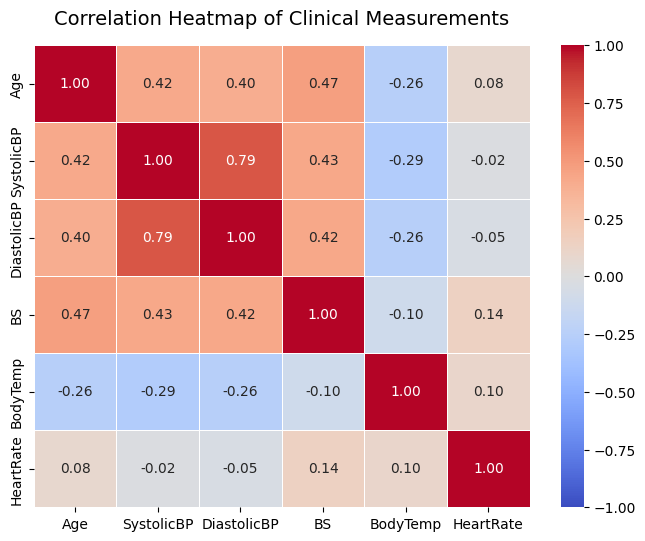

In [13]:

# 1. Correlation Heatmap (Feature-to-Feature)

plt.figure(figsize=(8, 6))

# use numeric_only = True so it ignores the text-based RiskLevel column
correlation_matrix = df.corr(numeric_only=True)

# Generate the heatmap
# annot=True puts the exact correlation numbers inside the squares

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Clinical Measurements', pad=15, fontsize=14)
plt.show()



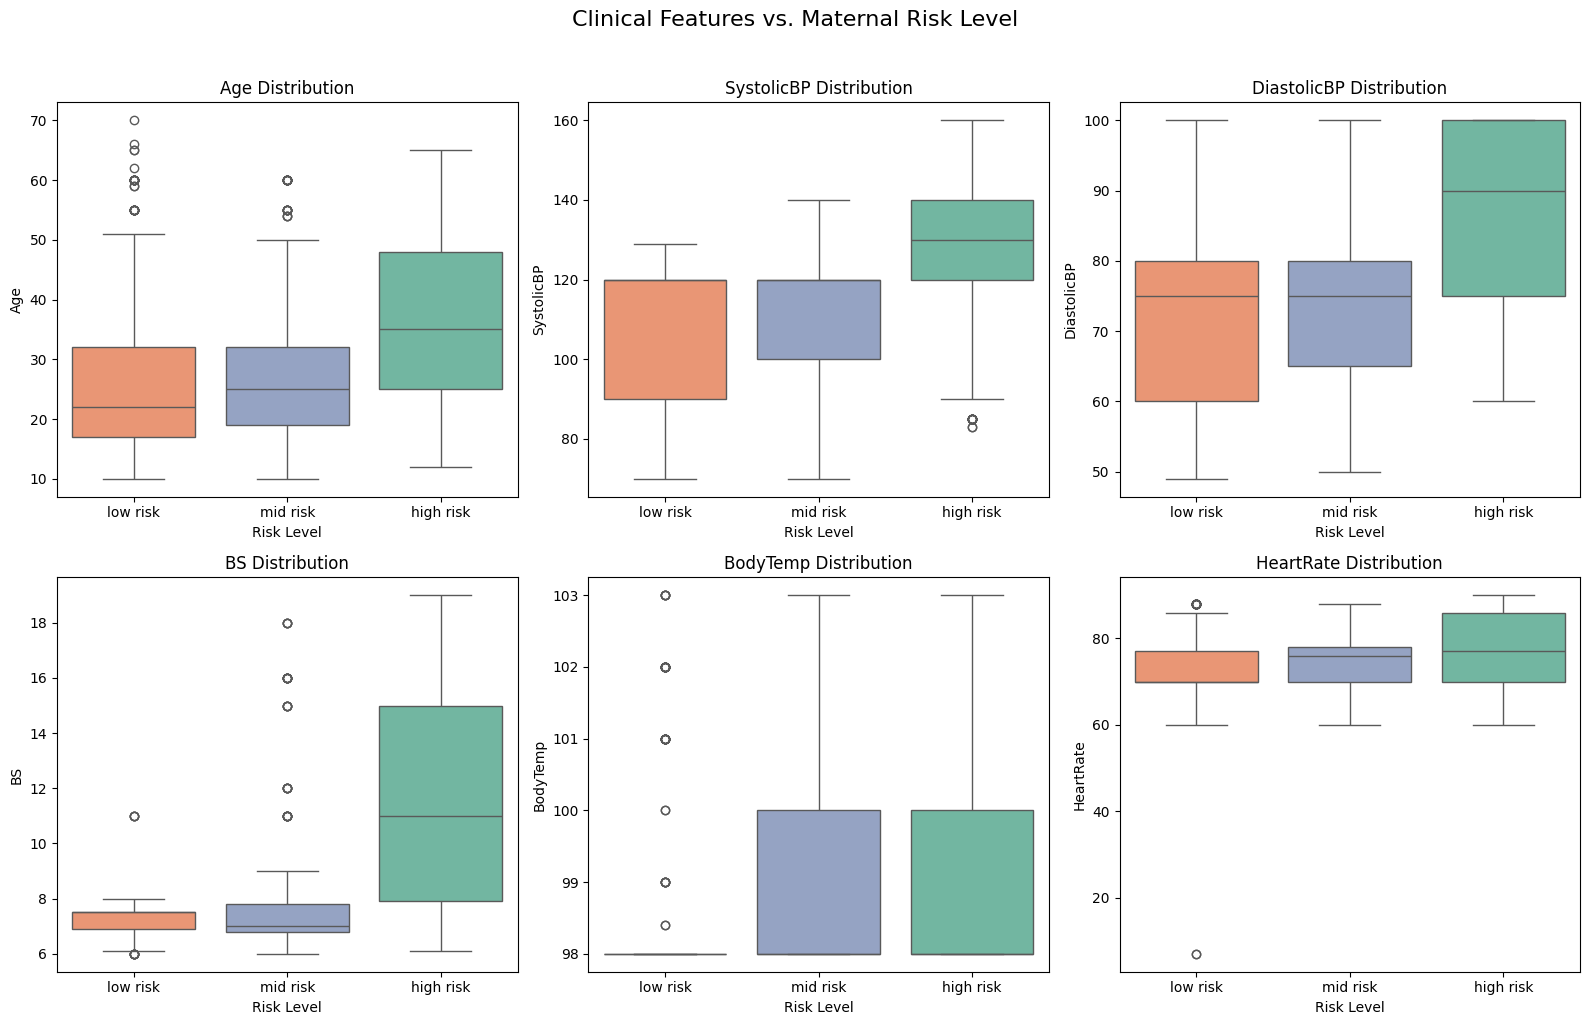

In [17]:

# 2. Boxplots (Feature-to-Target)
# List of 6 numerical columns

features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

# Create a 2x3 grid for the plots so they display cleanly together

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Clinical Features vs. Maternal Risk Level', fontsize=16, y=1.02)

# Flatten the 2D grid of axes into a 1D array so we can loop through it easily

axes = axes.flatten()

# Lock the order from Low to High for clinical readability
# Note: If you already ran your encoding step, change this to: risk_order = [0, 1, 2]

risk_order = ['low risk', 'mid risk', 'high risk']

# Loop through each feature and create a boxplot in its respective grid spot

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='RiskLevel', y=feature, order=risk_order, ax=axes[i], palette='Set2', hue='RiskLevel', legend=False)
    axes[i].set_title(f'{feature} Distribution', fontsize=12)
    axes[i].set_ylabel(feature)
    axes[i].set_xlabel('Risk Level')

# Automatically adjust spacing so titles and labels don't overlap
plt.tight_layout()
plt.show()

In [18]:
df['RiskLevel'].value_counts()

,count
RiskLevel,
low risk,406
mid risk,336
high risk,272


In [19]:
#encode the categorical variables

risk_level_mapping = {
    'low risk': 0,
    'mid risk': 1,
    'high risk': 2
}
df['RiskLevel'] = df['RiskLevel'].map(risk_level_mapping)

print("RiskLevel column after mapping:")
print(df['RiskLevel'].value_counts())
print("\nFirst 5 rows of the DataFrame with numerical RiskLevel:")
display(df.head())

RiskLevel column after mapping:
RiskLevel
0    406
1    336
2    272
Name: count, dtype: int64

First 5 rows of the DataFrame with numerical RiskLevel:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


In [20]:
# 1. Isolate Features (X) and Target (y)
# X contains all clinical measurements; y contains what I am trying to predict

X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

# 2. Perform the Split
# I use 80% of the data to train the model, and hold back 20% to test it.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# 3. Verify the split (Great to include in a project report)

print(f"Total patients: {len(df)}")
print(f"Patients in Training Set: {len(X_train)}")
print(f"Patients in Testing Set: {len(X_test)}")

Total patients: 1014
Patients in Training Set: 811
Patients in Testing Set: 203
